## Objective
Understand the raw dataset before any cleaning or transformation.

1. Load and inspect the raw dataset structure
2. Classify and filter loan_status — define resolved vs unresolved loans, justify 
   the 40.4% exclusion, and create the binary target variable (default_flag)
3. Analyse missing values across all 151 columns — tier columns by missing rate 
   and flag post-origination leakage
4. Understand distributions of numeric features — identify outliers, skew, 
   and impossible values
5. Understand categorical feature compositions — value counts, cardinality, 
   and default rate by category
6. Temporal analysis — loan volume and default rate by year, motivate 
   temporal train/test split
7. Feature correlation overview — numeric features vs default_flag, 
   and feature-feature multicollinearity
8. Summarise all findings as a cleaning checklist for Notebook 02

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import matplotlib.ticker as mtick

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")

pandas:       3.0.1
numpy:        2.4.3


## Section 1 - Data Loading and Overview 

In [2]:
# Load Raw Data
# Define paths
RAW_PATH = "../data/raw/loan.csv"

df_raw = pd.read_csv(RAW_PATH, low_memory=False)

print(f"Shape:    {df_raw.shape}")
print(f"Rows:     {df_raw.shape[0]:,}")
print(f"Columns:  {df_raw.shape[1]}")

Shape:    (2260701, 151)
Rows:     2,260,701
Columns:  151


In [3]:
# First few rows
df_raw.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,...,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0000,3600.0000,3600.0000,36 months,13.9900,123.0300,C,C4,leadman,10+ years,MORTGAGE,55000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.9100,0.0000,Aug-2003,675.0000,679.0000,1.0000,30.0000,NaN,7.0000,0.0000,2765.0000,29.7000,13.0000,w,0.0000,0.0000,4421.7239,4421.7200,3600.0000,821.7200,0.0000,0.0000,0.0000,Jan-2019,122.6700,NaN,...,4.0000,7.0000,0.0000,0.0000,0.0000,3.0000,76.9000,0.0000,0.0000,0.0000,178050.0000,7746.0000,2400.0000,13734.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0000,24700.0000,24700.0000,36 months,11.9900,820.2800,C,C1,Engineer,10+ years,MORTGAGE,65000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.0600,1.0000,Dec-1999,715.0000,719.0000,4.0000,6.0000,NaN,22.0000,0.0000,21470.0000,19.2000,38.0000,w,0.0000,0.0000,25679.6600,25679.6600,24700.0000,979.6600,0.0000,0.0000,0.0000,Jun-2016,926.3500,NaN,...,5.0000,22.0000,0.0000,0.0000,0.0000,2.0000,97.4000,7.7000,0.0000,0.0000,314017.0000,39475.0000,79300.0000,24667.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0000,20000.0000,20000.0000,60 months,10.7800,432.6600,B,B4,truck driver,10+ years,MORTGAGE,63000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.7800,0.0000,Aug-2000,695.0000,699.0000,0.0000,NaN,NaN,6.0000,0.0000,7869.0000,56.2000,18.0000,w,0.0000,0.0000,22705.9243,22705.9200,20000.0000,2705.9200,0.0000,0.0000,0.0000,Jun-2017,15813.3000,NaN,...,3.0000,6.0000,0.0000,0.0000,0.0000,0.0000,100.0000,50.0000,0.0000,0.0000,218418.0000,18696.0000,6200.0000,14877.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Column dtypes summary
dtype_counts = df_raw.dtypes.value_counts()
print("Column data types:")
print(dtype_counts)

Column data types:
float64    113
str         38
Name: count, dtype: int64


In [5]:
# Print all column names with their data type
col_info = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.values
}).reset_index(drop=True)

print(f"Total columns: {len(col_info)}\n")
for i, row in col_info.iterrows():
    print(f"{i+1:>3}.  {row['column']:<45} {str(row['dtype'])}")

Total columns: 151

  1.  id                                            str
  2.  member_id                                     float64
  3.  loan_amnt                                     float64
  4.  funded_amnt                                   float64
  5.  funded_amnt_inv                               float64
  6.  term                                          str
  7.  int_rate                                      float64
  8.  installment                                   float64
  9.  grade                                         str
 10.  sub_grade                                     str
 11.  emp_title                                     str
 12.  emp_length                                    str
 13.  home_ownership                                str
 14.  annual_inc                                    float64
 15.  verification_status                           str
 16.  issue_d                                       str
 17.  loan_status                                   str


In [6]:
# Column classification summary
groups = {
    "Administrative — drop":           ["id", "member_id", "url", "desc", "title", "zip_code", "policy_code"],
    "Loan terms — keep":               ["loan_amnt", "funded_amnt", "funded_amnt_inv", "term", "int_rate", 
                                        "installment", "grade", "sub_grade", "purpose"],
    "Borrower profile — keep":         ["emp_title", "emp_length", "home_ownership", "annual_inc", 
                                        "verification_status", "addr_state", "dti", 
                                        "fico_range_low", "fico_range_high"],
    "Credit bureau history — keep":    ["delinq_2yrs", "earliest_cr_line", "inq_last_6mths", 
                                        "mths_since_last_delinq", "open_acc", "pub_rec", 
                                        "revol_bal", "revol_util", "total_acc", "mort_acc"],
    "Post-origination — leakage":      ["out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
                                        "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
                                        "recoveries", "collection_recovery_fee", "last_pymnt_d",
                                        "last_pymnt_amnt", "next_pymnt_d", "last_credit_pull_d",
                                        "last_fico_range_high", "last_fico_range_low"],
    "Hardship and settlement — leakage": ["hardship_flag", "hardship_type", "hardship_reason",
                                          "hardship_status", "hardship_amount", "hardship_start_date",
                                          "hardship_end_date", "payment_plan_start_date",
                                          "debt_settlement_flag", "debt_settlement_flag_date",
                                          "settlement_status", "settlement_date", "settlement_amount",
                                          "settlement_percentage", "settlement_term"],
    "Joint application — mostly null": ["annual_inc_joint", "dti_joint", "verification_status_joint",
                                        "revol_bal_joint", "sec_app_fico_range_low", 
                                        "sec_app_fico_range_high", "sec_app_open_acc"],
    "Temporal — engineer from":        ["issue_d", "earliest_cr_line"],
    "Borderline — investigate":        ["pymnt_plan", "initial_list_status", "disbursement_method",
                                        "application_type"]
}

print("COLUMN CLASSIFICATION SUMMARY")
total = 0
for group, cols in groups.items():
    print(f"\n{group}")
    print(f"  Count: {len(cols)}")
    total += len(cols)
print(f"\nTotal catalogued: {total} / {df_raw.shape[1]}")
print(f"Uncatalogued (credit bureau detail): {df_raw.shape[1] - total}")


COLUMN CLASSIFICATION SUMMARY

Administrative — drop
  Count: 7

Loan terms — keep
  Count: 9

Borrower profile — keep
  Count: 9

Credit bureau history — keep
  Count: 10

Post-origination — leakage
  Count: 15

Hardship and settlement — leakage
  Count: 15

Joint application — mostly null
  Count: 7

Temporal — engineer from
  Count: 2

Borderline — investigate
  Count: 4

Total catalogued: 78 / 151
Uncatalogued (credit bureau detail): 73


## Section 2 — Target Variable Analysis

The target variable is `loan_status`. We need to understand:
1. What each status means
2. Which statuses represent a known outcome (resolved)
3. Which statuses are unresolved and must be excluded
4. What our final default rate will be after filtering

In [7]:
# Full distribution with percentages
status_counts = df_raw["loan_status"].value_counts()
status_pct = df_raw["loan_status"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": status_counts,
    "percentage": status_pct.round(2)
})

print("Loan Status Distribution:")
print(target_summary.to_string())
print(f"\nTotal rows: {len(df_raw):,}")


Loan Status Distribution:
                                                       count  percentage
loan_status                                                             
Fully Paid                                           1076751     47.6300
Current                                               878317     38.8500
Charged Off                                           268559     11.8800
Late (31-120 days)                                     21467      0.9500
In Grace Period                                         8436      0.3700
Late (16-30 days)                                       4349      0.1900
Does not meet the credit policy. Status:Fully Paid      1988      0.0900
Does not meet the credit policy. Status:Charged Off      761      0.0300
Default                                                   40      0.0000

Total rows: 2,260,701


In [8]:
# Classify statuses as resolved or unresolved
status_classification = {
    "Fully Paid":                                           "Resolved — Non-Default",
    "Does not meet the credit policy. Status:Fully Paid":  "Resolved — Non-Default",
    "Charged Off":                                         "Resolved — Default",
    "Default":                                             "Resolved — Default",
    "Does not meet the credit policy. Status:Charged Off": "Resolved — Default",
    "Current":                                             "Unresolved — Exclude",
    "Late (31-120 days)":                                  "Unresolved — Exclude",
    "In Grace Period":                                     "Unresolved — Exclude",
    "Late (16-30 days)":                                   "Unresolved — Exclude",
}

print(f"{'Loan Status':<55} {'Classification':<30} {'Count':>10}")
print("=" * 100)
for status, classification in status_classification.items():
    count = status_counts.get(status, 0)
    print(f"{status:<55} {classification:<30} {count:>10,}")

# Summary
resolved = sum(status_counts.get(s, 0) 
               for s, c in status_classification.items() 
               if "Resolved" in c)
unresolved = sum(status_counts.get(s, 0) 
                 for s, c in status_classification.items() 
                 if "Unresolved" in c)
defaults = sum(status_counts.get(s, 0) 
               for s, c in status_classification.items() 
               if "Default" in c)

print(f"\nResolved loans:         {resolved:>10,}  ({resolved/len(df_raw)*100:.1f}% of total)")
print(f"Unresolved loans:       {unresolved:>10,}  ({unresolved/len(df_raw)*100:.1f}% of total — will be dropped)")
print(f"\nOf resolved loans:")
print(f"  Defaults:             {defaults:>10,}  ({defaults/resolved*100:.2f}%)")
print(f"  Non-defaults:         {resolved-defaults:>10,}  ({(resolved-defaults)/resolved*100:.2f}%)")

Loan Status                                             Classification                      Count
Fully Paid                                              Resolved — Non-Default          1,076,751
Does not meet the credit policy. Status:Fully Paid      Resolved — Non-Default              1,988
Charged Off                                             Resolved — Default                268,559
Default                                                 Resolved — Default                     40
Does not meet the credit policy. Status:Charged Off     Resolved — Default                    761
Current                                                 Unresolved — Exclude              878,317
Late (31-120 days)                                      Unresolved — Exclude               21,467
In Grace Period                                         Unresolved — Exclude                8,436
Late (16-30 days)                                       Unresolved — Exclude                4,349

Resolved loans:    

In [9]:
defaults = sum(status_counts.get(s, 0) 
               for s, c in status_classification.items() 
               if c == "Resolved — Default")

non_defaults = sum(status_counts.get(s, 0) 
                   for s, c in status_classification.items() 
                   if c == "Resolved — Non-Default")

print(f"Defaults:     {defaults:,}  ({defaults/resolved*100:.2f}%)")
print(f"Non-defaults: {non_defaults:,}  ({non_defaults/resolved*100:.2f}%)")
print(f"Total resolved: {defaults + non_defaults:,}")

Defaults:     269,360  (19.98%)
Non-defaults: 1,078,739  (80.02%)
Total resolved: 1,348,099


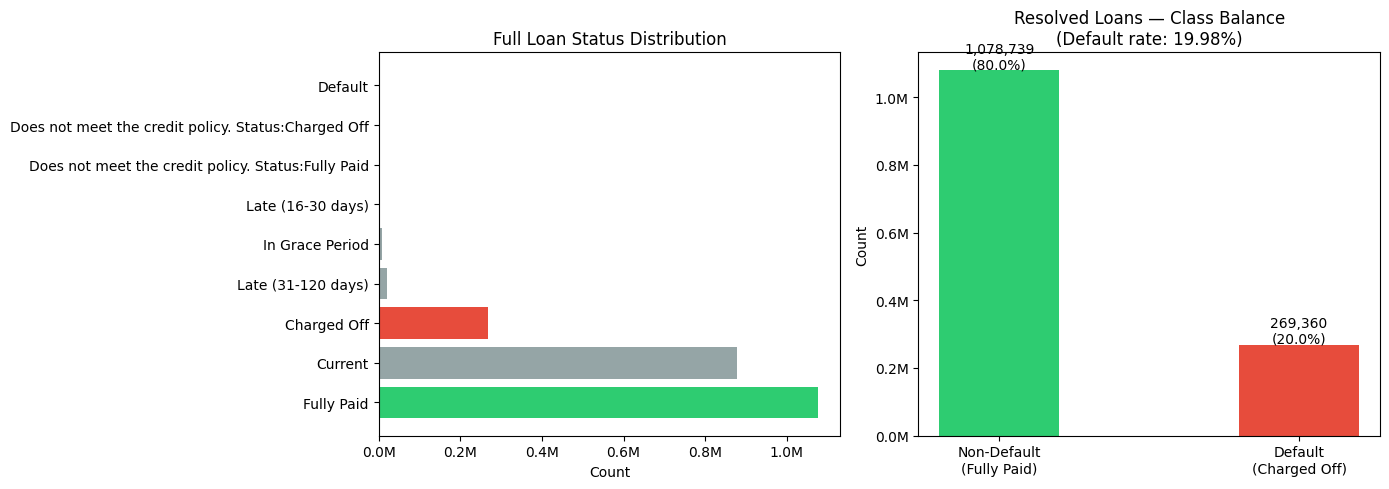

Chart saved to outputs/


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — full distribution
colors = ["#2ecc71" if "Fully" in s 
          else "#e74c3c" if s in ["Charged Off", "Default"] 
          else "#e74c3c" if "Charged" in s 
          else "#2ecc71" if "Fully" in s
          else "#95a5a6" 
          for s in status_counts.index]

axes[0].barh(status_counts.index, status_counts.values, color=colors)
axes[0].set_xlabel("Count")
axes[0].set_title("Full Loan Status Distribution")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Right — resolved only (what we will model)
resolved_labels = ["Non-Default\n(Fully Paid)", "Default\n(Charged Off)"]
resolved_values = [resolved - defaults, defaults]
resolved_colors = ["#2ecc71", "#e74c3c"]

axes[1].bar(resolved_labels, resolved_values, color=resolved_colors, width=0.4)
axes[1].set_title(f"Resolved Loans — Class Balance\n(Default rate: {defaults/resolved*100:.2f}%)")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

for i, v in enumerate(resolved_values):
    axes[1].text(i, v + 5000, f"{v:,}\n({v/resolved*100:.1f}%)", 
                 ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs/")

In [11]:
# Filter df_raw to resolved loans only
# Drop all unresolved statuses (Current, Late, In Grace Period)

resolved_statuses = {
    s for s, c in status_classification.items() 
    if "Resolved" in c
}

df_resolved = df_raw[df_raw["loan_status"].isin(resolved_statuses)].copy()

print(f"df_raw shape:      {df_raw.shape}")
print(f"df_resolved shape: {df_resolved.shape}")
print(f"Rows dropped:      {len(df_raw) - len(df_resolved):,} ({(1 - len(df_resolved)/len(df_raw))*100:.1f}%)")

df_raw shape:      (2260701, 151)
df_resolved shape: (1348099, 151)
Rows dropped:      912,602 (40.4%)


In [12]:
# Derive default_flag directly from status_classification

default_statuses = {
    s for s, c in status_classification.items() 
    if c == "Resolved — Default"
}

df_resolved["default_flag"] = df_resolved["loan_status"].isin(default_statuses).astype(int)

assert df_resolved["default_flag"].sum() == 269_360, "Default count mismatch"
assert len(df_resolved) == 1_348_099, "Resolved loan count mismatch"

print(f"default_flag created.")
print(f"  1 (Default):     {df_resolved['default_flag'].sum():>10,}")
print(f"  0 (Non-Default): {(df_resolved['default_flag'] == 0).sum():>10,}")
print(f"  Total:           {len(df_resolved):>10,}")

default_flag created.
  1 (Default):        269,360
  0 (Non-Default):  1,078,739
  Total:            1,348,099


## Section 3: Missing Value Analysis
- Computes missing count, missing percentage, and dtype for every column
- Visualises the missing rate distribution across all 151 columns
- Classifies columns into three tiers based on missing rate:
    - **Drop** (>50% missing) — too sparse to impute reliably
    - **Impute** (5–50% missing) — salvageable with appropriate strategy in Notebook 02
    - **Complete** (<5% missing) — usable with minimal intervention
- Separately flags post-origination leakage columns — these are dropped not 
  because of missingness but because they contain information that would not 
  be available at loan application time

In [13]:
def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    total = len(df)
    missing_count = df.isnull().sum()
    missing_pct   = (missing_count / total * 100).round(2)
    dtype         = df.dtypes

    summary = pd.DataFrame({
        "missing_count" : missing_count,
        "missing_pct"   : missing_pct,
        "dtype"         : dtype
    })

    summary = summary[summary["missing_count"] > 0]
    summary = summary.sort_values("missing_pct", ascending=False)

    return summary


miss = missing_summary(df_resolved)
print(f"Total columns:              {df_resolved.shape[1]}")
print(f"Columns with missing values: {len(miss)}")
print(f"Columns fully complete:      {df_resolved.shape[1] - len(miss)}")
print()
miss

Total columns:              152
Columns with missing values: 113
Columns fully complete:      39



,missing_count,missing_pct,dtype
member_id,1348099,100.0000,float64
next_pymnt_d,1345310,99.7900,str
orig_projected_additional_accrued_interest,1344338,99.7200,float64
hardship_status,1342343,99.5700,str
hardship_length,1342343,99.5700,float64
...,...,...,...
last_credit_pull_d,57,0.0000,str
zip_code,1,0.0000,str
acc_now_delinq,29,0.0000,float64
annual_inc,4,0.0000,float64


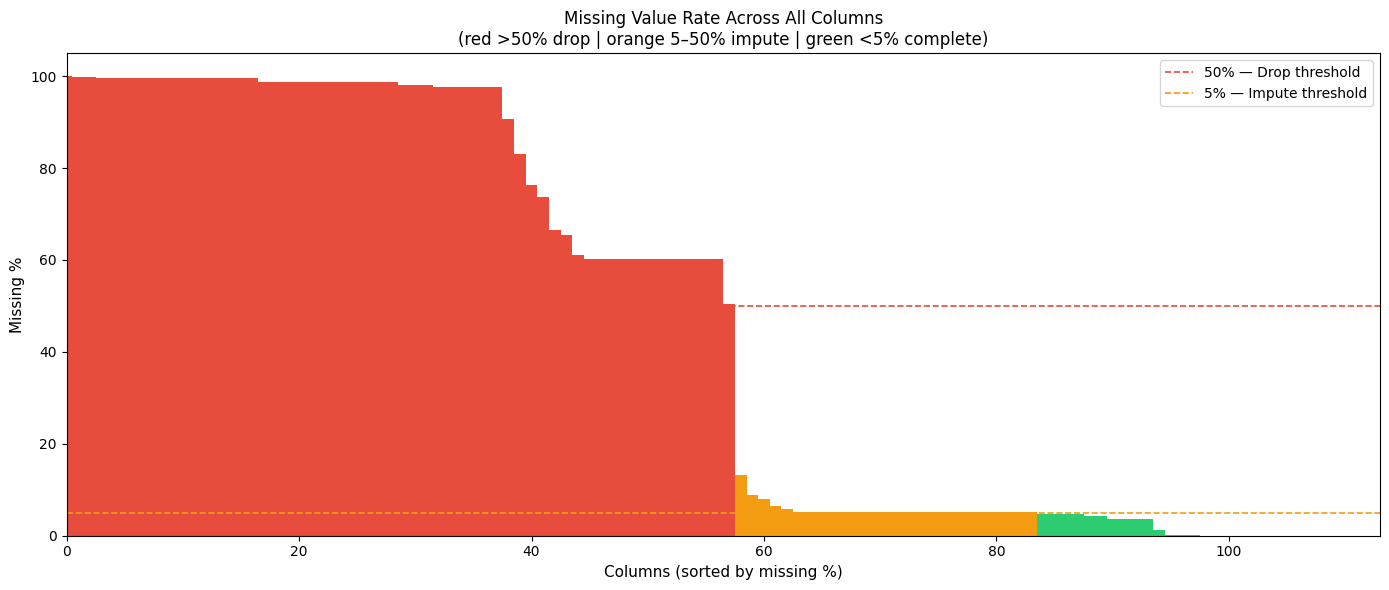

Chart saved.


In [14]:
# Visualise missing rate distribution across all columns

fig, ax = plt.subplots(figsize=(14, 6))

# Colour by tier
colors = [
    "#e74c3c" if pct > 50 
    else "#f39c12" if pct >= 5 
    else "#2ecc71" 
    for pct in miss["missing_pct"]
]

ax.bar(range(len(miss)), miss["missing_pct"], color=colors, width=1.0)

ax.axhline(y=50, color="#e74c3c", linestyle="--", linewidth=1.2, label="50% — Drop threshold")
ax.axhline(y=5,  color="#f39c12", linestyle="--", linewidth=1.2, label="5% — Impute threshold")

ax.set_xlabel("Columns (sorted by missing %)", fontsize=11)
ax.set_ylabel("Missing %", fontsize=11)
ax.set_title("Missing Value Rate Across All Columns\n(red >50% drop | orange 5–50% impute | green <5% complete)", fontsize=12)
ax.legend()
ax.set_xlim(0, len(miss))
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("../outputs/missing_value_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [15]:
# Classify columns into tiers by missing rate

tier_drop     = miss[miss["missing_pct"] > 50]
tier_impute   = miss[(miss["missing_pct"] >= 5) & (miss["missing_pct"] <= 50)]
tier_complete = miss[miss["missing_pct"] < 5]

print(f"Tier 1 — DROP     (>50% missing):   {len(tier_drop):>3} columns")
print(f"Tier 2 — IMPUTE   (5–50% missing):  {len(tier_impute):>3} columns")
print(f"Tier 3 — COMPLETE (<5% missing):    {len(tier_complete):>3} columns")
print()
print("Tier 1 (Drop)")
print(tier_drop[["missing_pct", "dtype"]].to_string())
print()
print("Tier 2 (Impute)")
print(tier_impute[["missing_pct", "dtype"]].to_string())
print()
print("Tier 3 (Complete)")
print(tier_complete[["missing_pct", "dtype"]].to_string())

Tier 1 — DROP     (>50% missing):    58 columns
Tier 2 — IMPUTE   (5–50% missing):   26 columns
Tier 3 — COMPLETE (<5% missing):     29 columns

Tier 1 (Drop)
                                            missing_pct    dtype
member_id                                      100.0000  float64
next_pymnt_d                                    99.7900      str
orig_projected_additional_accrued_interest      99.7200  float64
hardship_status                                 99.5700      str
hardship_length                                 99.5700  float64
hardship_type                                   99.5700      str
hardship_reason                                 99.5700      str
deferral_term                                   99.5700  float64
hardship_amount                                 99.5700  float64
hardship_start_date                             99.5700      str
payment_plan_start_date                         99.5700      str
hardship_end_date                               99.5700      

In [16]:
# Flag post-origination leakage columns explicitly
# These are dropped not because of missingness but because they contain
# information unavailable at loan application time

leakage_columns = [
    # Payment history — post-origination
    "out_prncp", "out_prncp_inv",
    "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d",
    "last_credit_pull_d",
    # Last FICO — pulled post-origination
    "last_fico_range_high", "last_fico_range_low",
    # Hardship — post-origination workout programme
    "hardship_flag", "hardship_type", "hardship_reason", "hardship_status",
    "deferral_term", "hardship_amount", "hardship_start_date",
    "hardship_end_date", "hardship_length", "hardship_dpd",
    "hardship_loan_status", "hardship_payoff_balance_amount",
    "hardship_last_payment_amount", "payment_plan_start_date",
    "orig_projected_additional_accrued_interest",
    # Settlement — post-origination debt workout
    "settlement_amount", "settlement_percentage", "settlement_term",
    "settlement_status", "settlement_date", "debt_settlement_flag_date",
]

# Check which leakage columns are actually present in df_resolved
leakage_present = [c for c in leakage_columns if c in df_resolved.columns]
leakage_missing = [c for c in leakage_columns if c not in df_resolved.columns]

print(f"Leakage columns present in df_resolved: {len(leakage_present)}")
print(f"Leakage columns not found (already absent): {len(leakage_missing)}")
print()
print("Present leakage columns:")
for c in leakage_present:
    print(f"  {c}")

Leakage columns present in df_resolved: 36
Leakage columns not found (already absent): 0

Present leakage columns:
  out_prncp
  out_prncp_inv
  total_pymnt
  total_pymnt_inv
  total_rec_prncp
  total_rec_int
  total_rec_late_fee
  recoveries
  collection_recovery_fee
  last_pymnt_d
  last_pymnt_amnt
  next_pymnt_d
  last_credit_pull_d
  last_fico_range_high
  last_fico_range_low
  hardship_flag
  hardship_type
  hardship_reason
  hardship_status
  deferral_term
  hardship_amount
  hardship_start_date
  hardship_end_date
  hardship_length
  hardship_dpd
  hardship_loan_status
  hardship_payoff_balance_amount
  hardship_last_payment_amount
  payment_plan_start_date
  orig_projected_additional_accrued_interest
  settlement_amount
  settlement_percentage
  settlement_term
  settlement_status
  settlement_date
  debt_settlement_flag_date



#### Missing Value Tiers

| Tier | Threshold | Count | Action |
|------|-----------|-------|--------|
| 1 | >50% missing | 58 columns | Drop |
| 2 | 5–50% missing | 26 columns | Impute |
| 3 | <5% missing | 29 columns | Use with minimal intervention |

**Tier 1 — Drop (58 columns)**
- Hardship block (~99.57% missing) — post-origination workout programme
- Settlement block (~97.53% missing) — post-origination debt settlement
- Joint application block (~98% missing) — sparse because most loans are individual
- Most `mths_since_*` columns (66–83% missing) — informative but too sparse
- `member_id` (100% missing) — administrative, no signal

**Tier 2 — Impute (26 columns)**
- `num_*` / `mo_sin_*` credit bureau block — all at exactly 5.21% missing,
  meaning they were added to Lending Club data at the same point in time.
  Nearly all training data (2007–2015) will be missing these. Decision deferred
  to Notebook 02 after temporal coverage analysis in Section 7.
- `emp_title` (6.38%) and `emp_length` (5.83%) — borrower-reported, genuine
  missingness. `emp_length` → impute with "Unknown". `emp_title` → likely drop
  in feature engineering due to high cardinality.
- `mths_since_recent_inq` (13.12%) — missing means no recent inquiry.
  Impute with large sentinel value (e.g. 999).
- `mths_since_last_delinq` (50.4%) — sits exactly on the threshold. Missing
  means never delinquent. Create `ever_delinq` binary indicator alongside
  imputed value in Notebook 02.

**Tier 3 — Complete (29 columns)**
- Mostly usable with minimal intervention.
- **Exceptions — leakage despite low missingness:**
  - `last_pymnt_d`, `last_credit_pull_d` — post-origination dates, drop
  - `zip_code` — administrative, drop
  - `title` — free text, high cardinality, review in feature engineering

---

#### Post-Origination Leakage — 36 Columns Identified

These columns are dropped not because of missing values but because they contain
information that does not exist at loan application time. Using them would cause
the model to learn from the future — strong in-sample performance, complete
failure in production.

- **Payment history block** — `out_prncp`, `total_pymnt`, `recoveries`, etc.
- **Last FICO block** — `last_fico_range_high`, `last_fico_range_low`
- **Hardship block** — all `hardship_*` columns
- **Settlement block** — all `settlement_*` columns

## Section 4: Numeric Feature Distributions 


In [17]:
numeric_features = [
    # Loan terms
    "loan_amnt", "funded_amnt", "int_rate", "installment",
    # Borrower profile
    "annual_inc", "dti", "fico_range_low", "fico_range_high",
    # Credit bureau history
    "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc", "mort_acc"
]

df_default     = df_resolved[df_resolved["default_flag"] == 1]
df_nondefault  = df_resolved[df_resolved["default_flag"] == 0]

print(f"Defaulters:     {len(df_default):>10,}")
print(f"Non-defaulters: {len(df_nondefault):>10,}")
print(f"Features to plot: {len(numeric_features)}")

Defaulters:        269,360
Non-defaulters:  1,078,739
Features to plot: 16


In [18]:
# Cell 4.2 — Distribution plots: defaulters vs non-defaulters
# Split into two figures of 8 plots each for readability

def plot_distributions(features, title_suffix, filename):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, col in enumerate(features):
        ax = axes[i]

        cap = df_resolved[col].quantile(0.99)
        d0  = df_nondefault[col].dropna().clip(upper=cap)
        d1  = df_default[col].dropna().clip(upper=cap)

        ax.hist(d0, bins=50, alpha=0.5, color="#2ecc71", density=True, label="Non-Default")
        ax.hist(d1, bins=50, alpha=0.5, color="#e74c3c", density=True, label="Default")

        ax.axvline(d0.median(), color="#27ae60", linestyle="--", linewidth=1.2)
        ax.axvline(d1.median(), color="#c0392b", linestyle="--", linewidth=1.2)

        ax.set_title(col, fontsize=11, fontweight="bold")
        ax.set_ylabel("Density", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=8, loc="upper right")

    plt.suptitle(
        f"Numeric Feature Distributions — Default vs Non-Default\n"
        f"{title_suffix} | capped at 99th percentile | dashed lines = medians",
        fontsize=13, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.savefig(f"../outputs/{filename}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: outputs/{filename}")


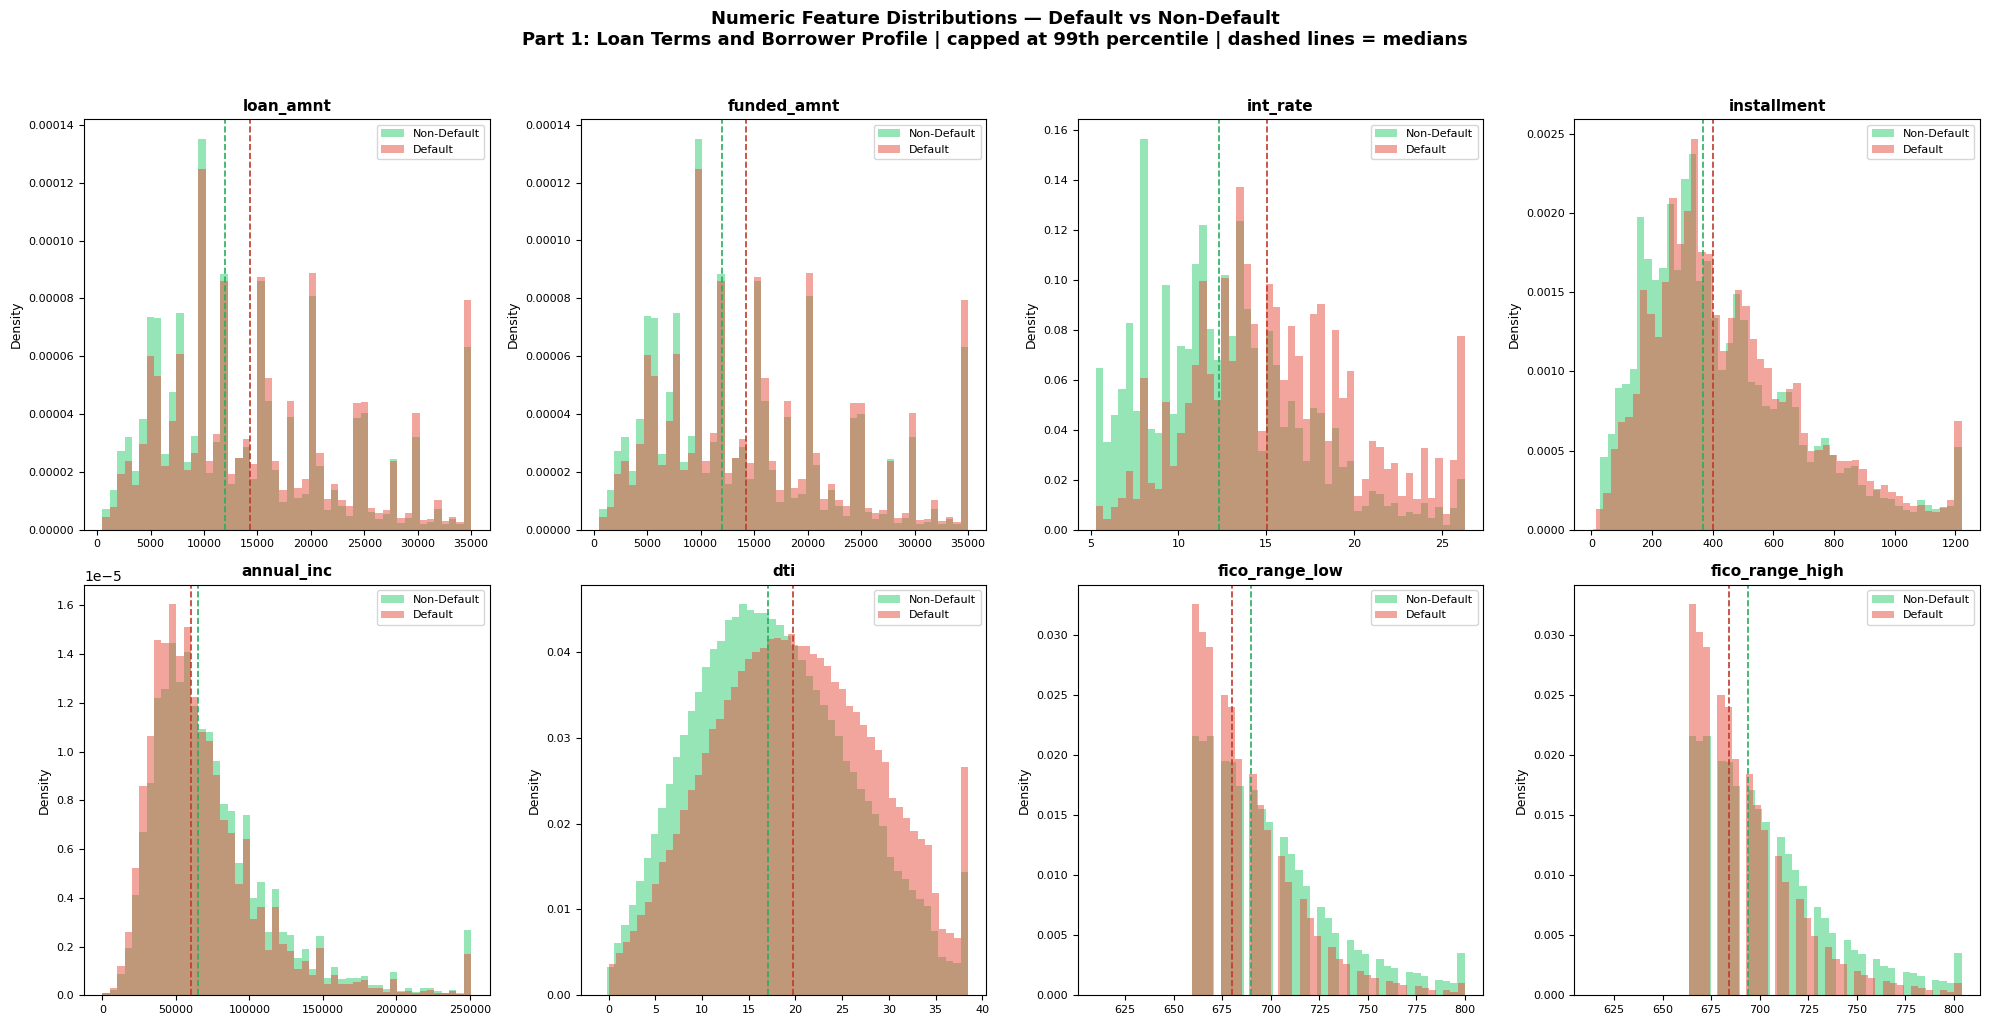

Saved: outputs/numeric_distributions_part1.png


In [19]:

# Figure 1 — Loan terms and borrower profile
plot_distributions(
    features      = ["loan_amnt", "funded_amnt", "int_rate", "installment",
                     "annual_inc", "dti", "fico_range_low", "fico_range_high"],
    title_suffix  = "Part 1: Loan Terms and Borrower Profile",
    filename      = "numeric_distributions_part1.png"
)

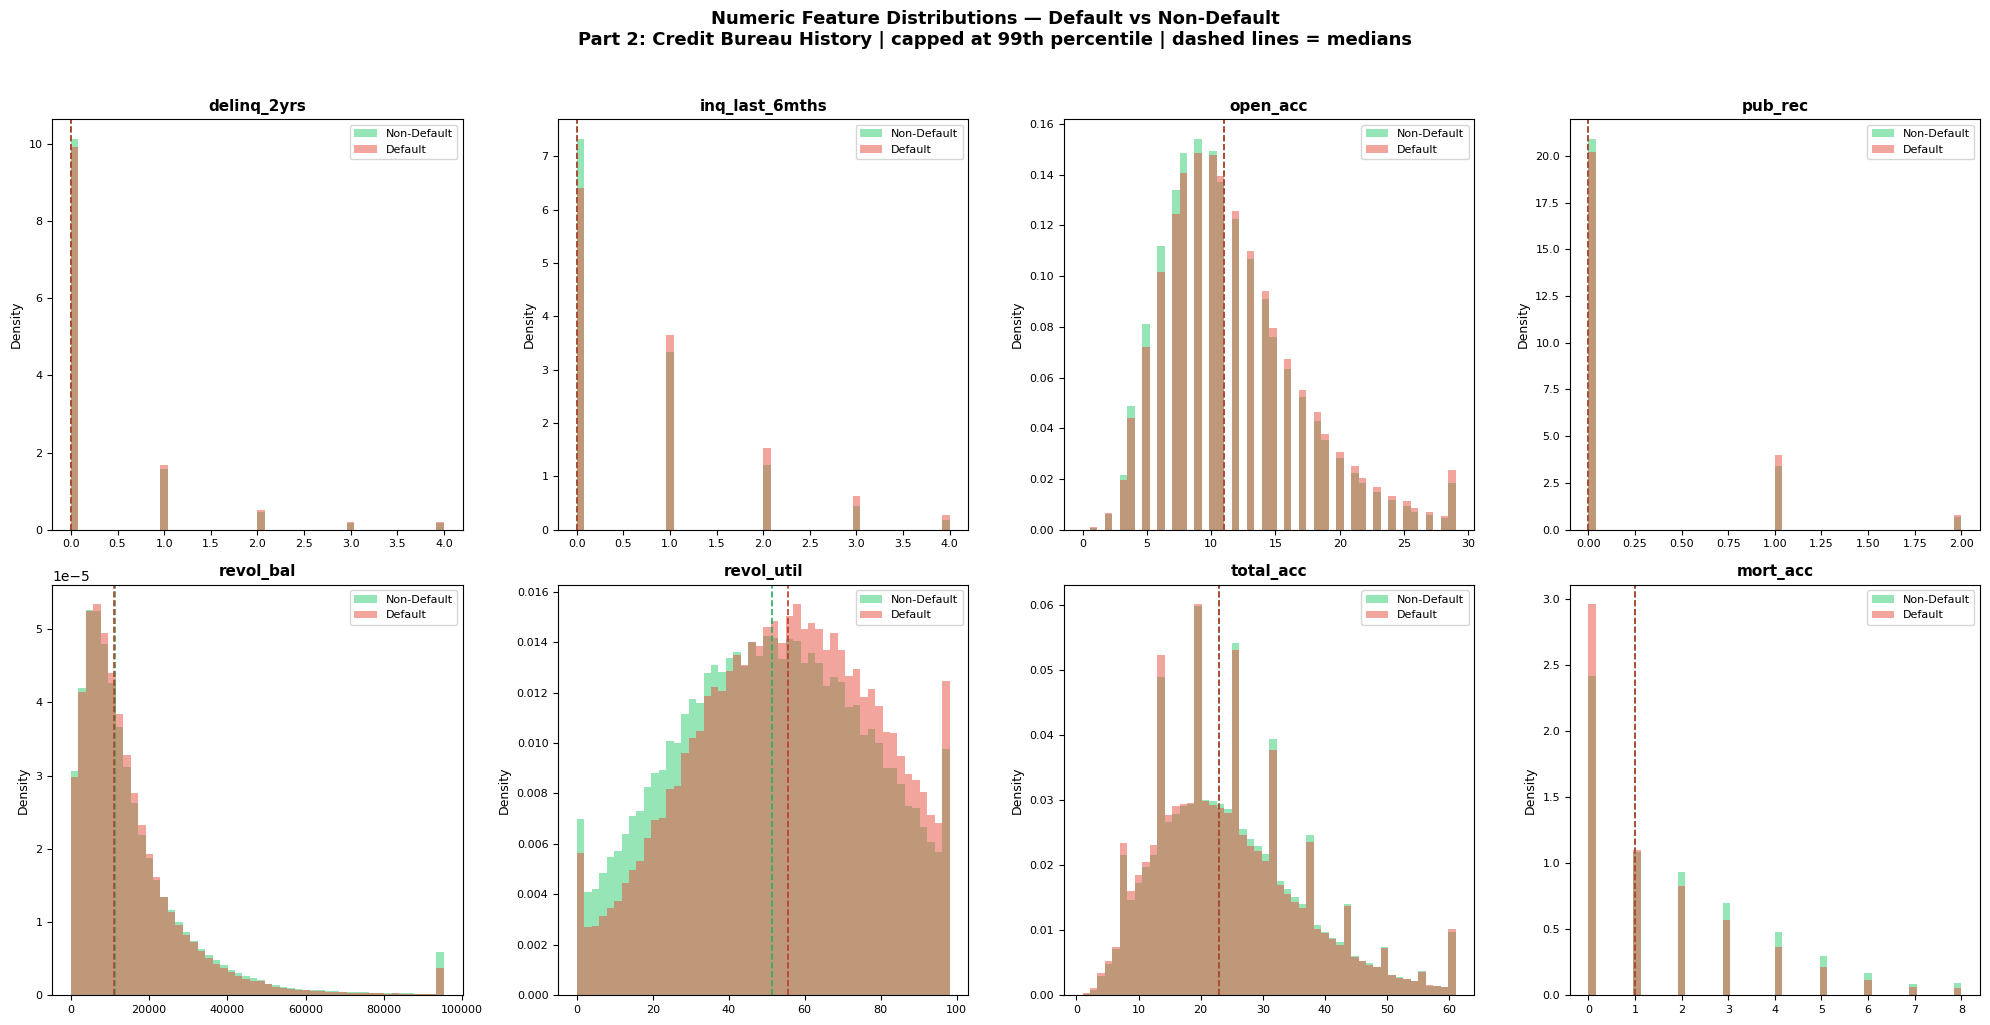

Saved: outputs/numeric_distributions_part2.png


In [20]:

# Figure 2 — Credit bureau history
plot_distributions(
    features      = ["delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec",
                     "revol_bal", "revol_util", "total_acc", "mort_acc"],
    title_suffix  = "Part 2: Credit Bureau History",
    filename      = "numeric_distributions_part2.png"
)

In [21]:
# Median comparison table: defaulters vs non-defaulters

rows = []
for col in numeric_features:
    med_0  = df_nondefault[col].median()
    med_1  = df_default[col].median()
    mean_0 = df_nondefault[col].mean()
    mean_1 = df_default[col].mean()
    null_pct = df_resolved[col].isnull().mean() * 100

    rows.append({
        "feature"        : col,
        "median_nondefault" : round(med_0, 2),
        "median_default"    : round(med_1, 2),
        "median_diff_%"     : round((med_1 - med_0) / (med_0 + 1e-9) * 100, 1),
        "mean_nondefault"   : round(mean_0, 2),
        "mean_default"      : round(mean_1, 2),
        "missing_%"         : round(null_pct, 2)
    })

stats_df = pd.DataFrame(rows).set_index("feature")

# Sort by absolute median difference descending — most separating features first
stats_df = stats_df.reindex(
    stats_df["median_diff_%"].abs().sort_values(ascending=False).index
)

print("Numeric features ranked by median separation (defaulters vs non-defaulters):")
print()
print(stats_df.to_string())

Numeric features ranked by median separation (defaulters vs non-defaulters):

                 median_nondefault  median_default  median_diff_%  mean_nondefault  mean_default  missing_%
feature                                                                                                    
int_rate                   12.2900         15.0500        22.5000          12.6300       15.7100     0.0000
loan_amnt               12000.0000      14300.0000        19.2000       14124.6400    15547.8200     0.0000
funded_amnt             12000.0000      14250.0000        18.7000       14115.8100    15539.0600     0.0000
dti                        17.1000         19.7500        15.5000          17.8000       20.1500     0.0300
installment               367.8000        402.5400         9.4000         431.0600      464.6900     0.0000
revol_util                 51.3000         55.5000         8.2000          51.0800       54.7600     0.0700
annual_inc              65000.0000      60000.0000        

**Strongest separators (median difference >10%):**
- `int_rate` (+22.5%) — most informative single feature; encodes Lending Club's
  own risk assessment at origination
- `loan_amnt` / `funded_amnt` (+19%, +18.7%) — nearly identical columns,
  one will be dropped as redundant in feature engineering
- `dti` (+15.5%) — core underwriting variable, clean separation

**Moderate separators (5–10%):**
- `installment` (+9.4%) — mechanically derived from loan_amnt and int_rate,
  low independent information content
- `revol_util` (+8.2%) — credit utilisation behaviour, meaningful signal
- `annual_inc` (−7.7%) — defaulters have lower income; right-skewed,
  log transformation required

**Weak median separation but not useless:**
- `fico_range_low` / `fico_range_high` (−1.4%) — compressed range due to
  Lending Club's own rejection filter (selection bias)
- Count variables (`delinq_2yrs`, `inq_last_6mths`, `pub_rec`, etc.) — median
  is 0 for both groups due to zero inflation; mean differences exist and
  WoE encoding will capture their predictive value

## Section 5: Categorical Feature Analysis 

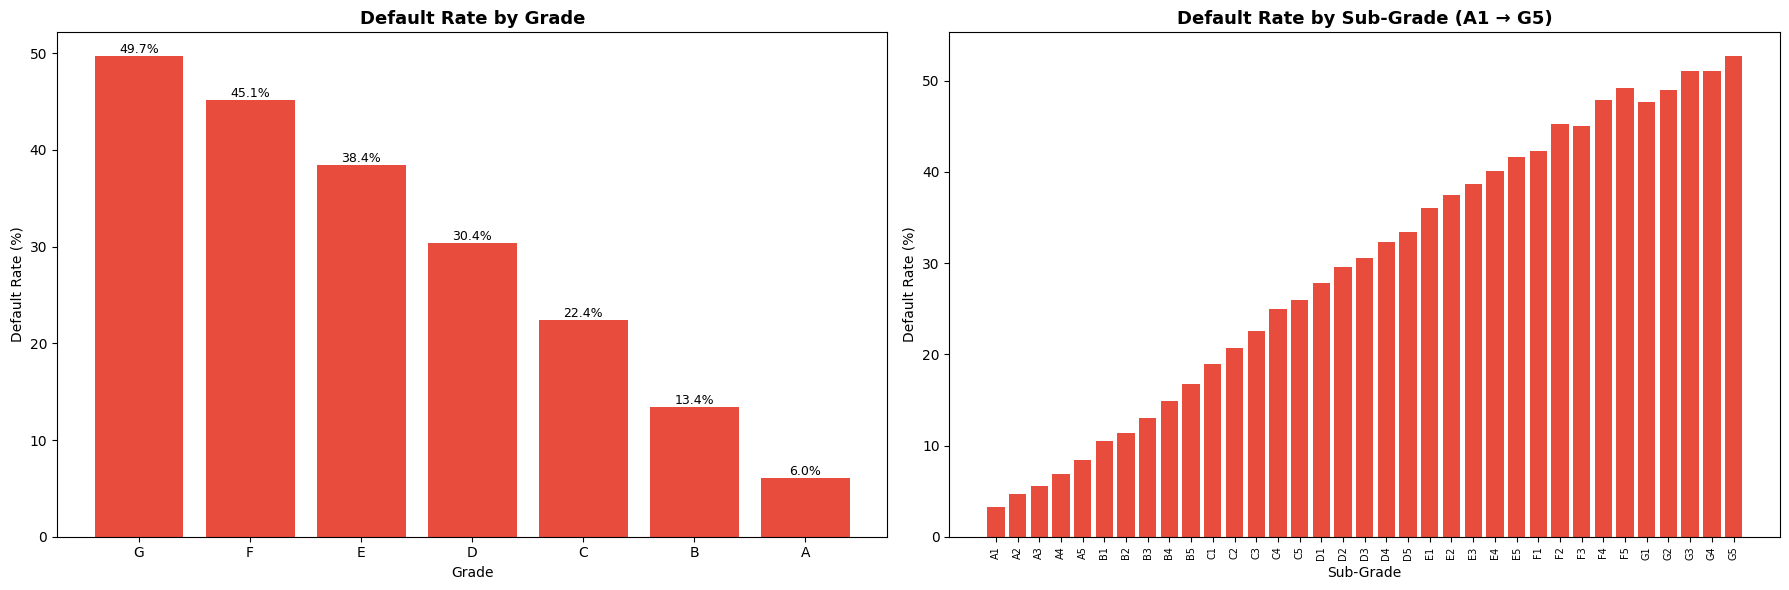

Saved: outputs/default_rate_grade_subgrade.png


In [22]:
def default_rate_by_category(df, col, min_count=100):
    """
    Returns a DataFrame with value counts and default rate per category.
    Filters out categories with fewer than min_count observations.
    """
    grouped = df.groupby(col)["default_flag"].agg(
        count="count",
        defaults="sum"
    ).reset_index()
    grouped["default_rate"] = (grouped["defaults"] / grouped["count"] * 100).round(2)
    grouped = grouped[grouped["count"] >= min_count]
    return grouped.sort_values("default_rate", ascending=False)


grade_stats = default_rate_by_category(df_resolved, "grade")

subgrade_stats = default_rate_by_category(df_resolved, "sub_grade")
# Sort by sub_grade label order (A1 → G5)
subgrade_order = [f"{g}{n}" for g in "ABCDEFG" for n in range(1, 6)]
subgrade_stats["sub_grade"] = pd.Categorical(
    subgrade_stats["sub_grade"], categories=subgrade_order, ordered=True
)
subgrade_stats = subgrade_stats.sort_values("sub_grade")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grade — sorted by default rate
axes[0].bar(
    grade_stats["grade"],
    grade_stats["default_rate"],
    color="#e74c3c"
)
axes[0].set_title("Default Rate by Grade", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Default Rate (%)")
for i, row in grade_stats.iterrows():
    axes[0].text(
        row["grade"], row["default_rate"] + 0.3,
        f"{row['default_rate']:.1f}%", ha="center", fontsize=9
    )

# Sub-grade — sorted A1 to G5
axes[1].bar(
    subgrade_stats["sub_grade"].astype(str),
    subgrade_stats["default_rate"],
    color="#e74c3c"
)
axes[1].set_title("Default Rate by Sub-Grade (A1 → G5)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Sub-Grade")
axes[1].set_ylabel("Default Rate (%)")
axes[1].tick_params(axis="x", rotation=90, labelsize=7)

plt.tight_layout()
plt.savefig("../outputs/default_rate_grade_subgrade.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/default_rate_grade_subgrade.png")

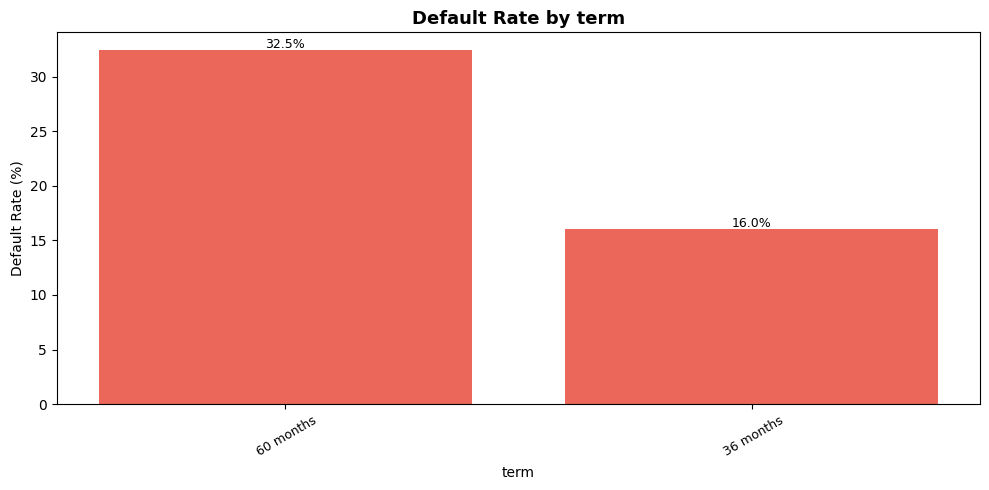

Saved: outputs/default_rate_term.png


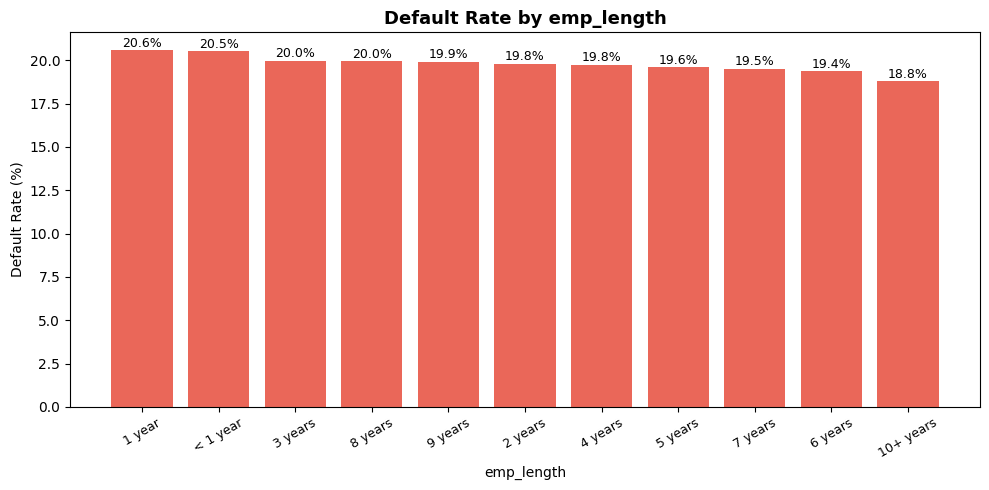

Saved: outputs/default_rate_emp_length.png


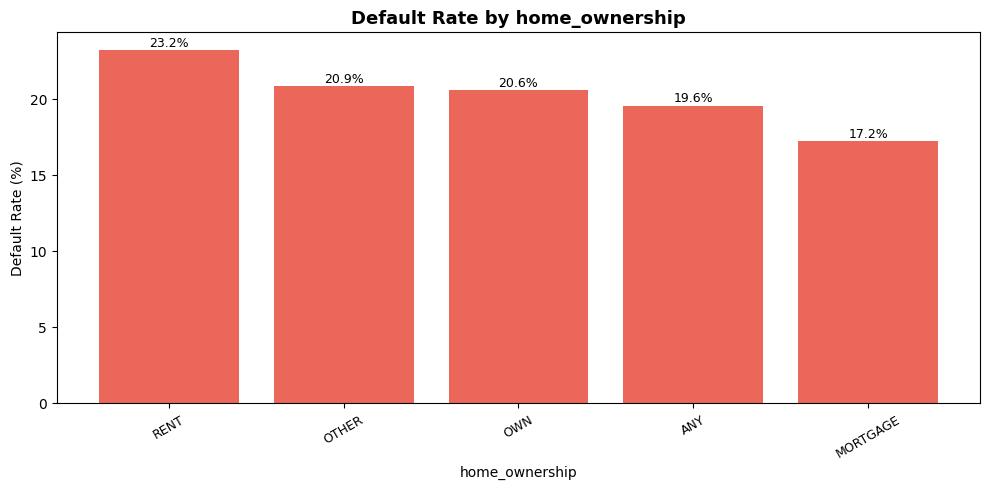

Saved: outputs/default_rate_home_ownership.png


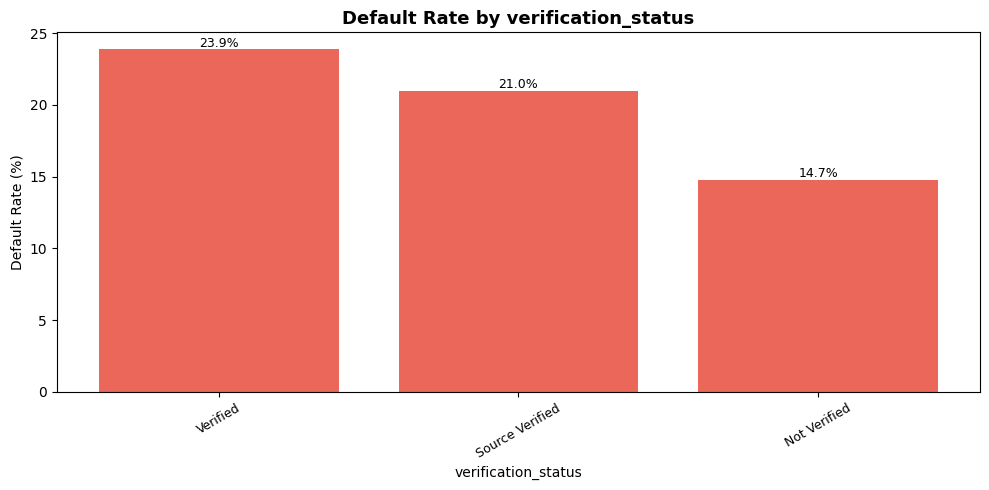

Saved: outputs/default_rate_verification_status.png


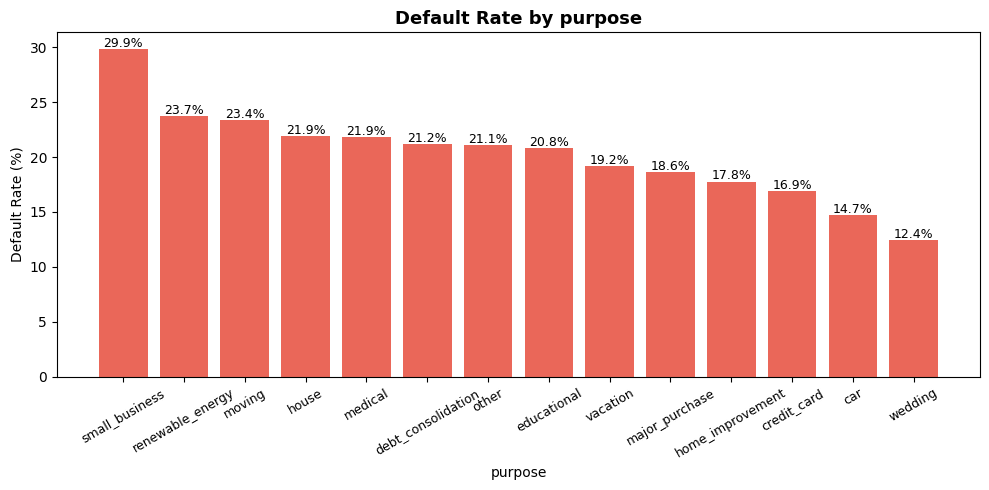

Saved: outputs/default_rate_purpose.png


In [23]:
features_cat = [
    "term", "emp_length", "home_ownership",
    "verification_status", "purpose"
]

for col in features_cat:
    stats = default_rate_by_category(df_resolved, col)
    stats = stats.sort_values("default_rate", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(
        stats[col].astype(str),
        stats["default_rate"],
        color="#e74c3c",
        alpha=0.85
    )

    ax.set_title(f"Default Rate by {col}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Default Rate (%)")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=30, labelsize=9)

    for bar, rate in zip(bars, stats["default_rate"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{rate:.1f}%", ha="center", fontsize=9
        )

    plt.tight_layout()
    plt.savefig(f"../outputs/default_rate_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: outputs/default_rate_{col}.png")

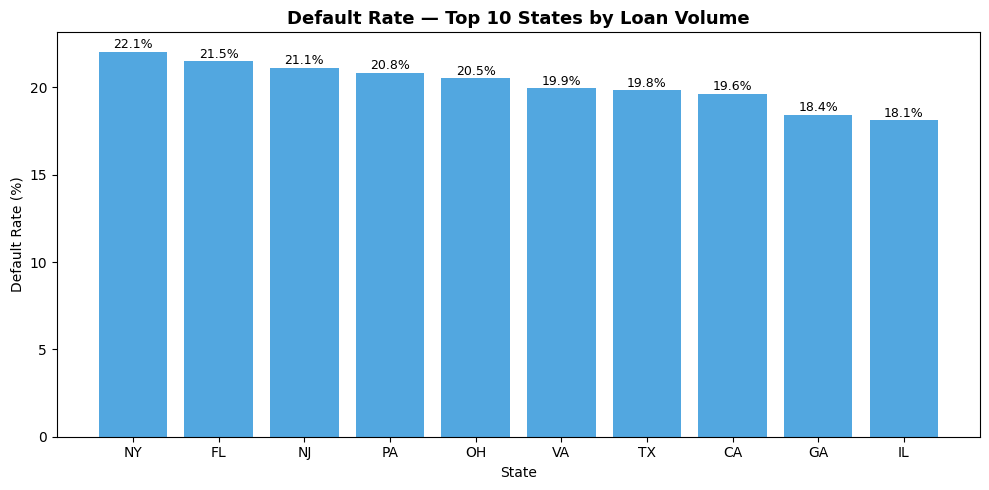

Saved: outputs/default_rate_addr_state.png


In [24]:
state_stats = default_rate_by_category(df_resolved, "addr_state")
top10_states = df_resolved["addr_state"].value_counts().head(10).index.tolist()
state_top10  = state_stats[state_stats["addr_state"].isin(top10_states)]
state_top10  = state_top10.sort_values("default_rate", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(state_top10["addr_state"], state_top10["default_rate"],
              color="#3498db", alpha=0.85)
ax.set_title("Default Rate — Top 10 States by Loan Volume",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Default Rate (%)")
ax.set_xlabel("State")
ax.tick_params(axis="x", rotation=0, labelsize=10)
for bar, rate in zip(bars, state_top10["default_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{rate:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/default_rate_addr_state.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/default_rate_addr_state.png")

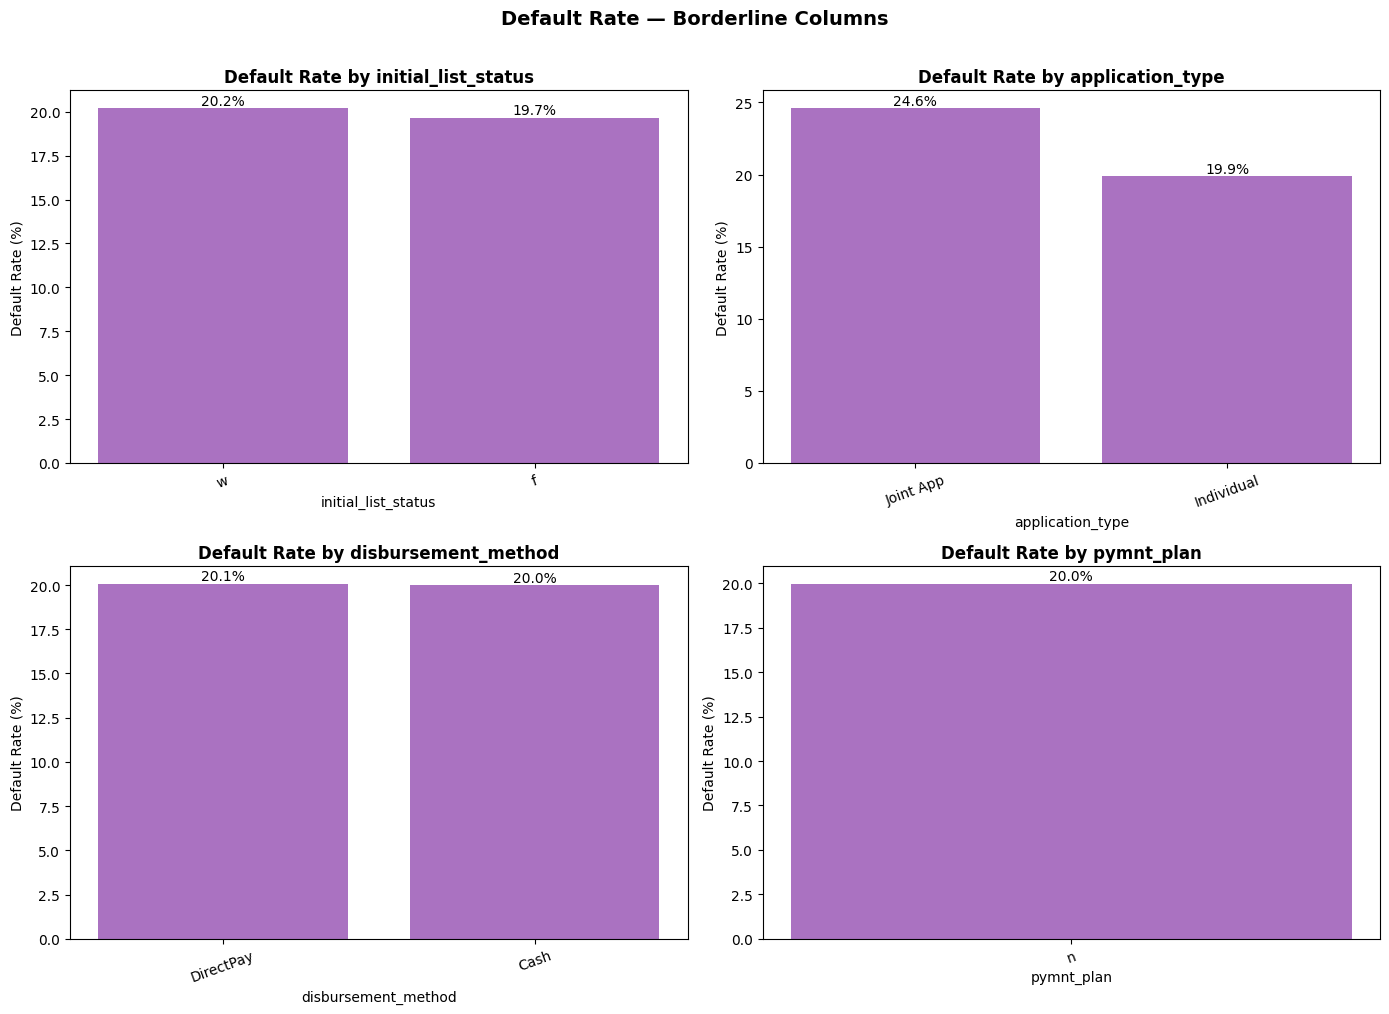

Saved: outputs/default_rate_borderline.png


In [25]:
borderline_cols = ["initial_list_status", "application_type",
                   "disbursement_method", "pymnt_plan"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(borderline_cols):
    stats = default_rate_by_category(df_resolved, col)
    stats = stats.sort_values("default_rate", ascending=False)

    bars = axes[i].bar(stats[col].astype(str), stats["default_rate"],
                       color="#9b59b6", alpha=0.85)
    axes[i].set_title(f"Default Rate by {col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Default Rate (%)")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=20, labelsize=10)

    for bar, rate in zip(bars, stats["default_rate"]):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.2,
                     f"{rate:.1f}%", ha="center", fontsize=10)

plt.suptitle("Default Rate — Borderline Columns",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/default_rate_borderline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/default_rate_borderline.png")

In [26]:
# Default rate summary for all categorical features

all_cat_cols = [
    "grade", "term", "emp_length", "home_ownership",
    "verification_status", "purpose",
    "initial_list_status", "application_type",
    "disbursement_method", "pymnt_plan"
]

print(f"{'Column':<25} {'Categories':>10} {'Min DR%':>8} {'Max DR%':>8} {'Range':>8}")
print("─" * 65)

for col in all_cat_cols:
    stats = default_rate_by_category(df_resolved, col)
    n_cats = len(stats)
    min_dr = stats["default_rate"].min()
    max_dr = stats["default_rate"].max()
    dr_range = max_dr - min_dr
    print(f"{col:<25} {n_cats:>10} {min_dr:>8.1f} {max_dr:>8.1f} {dr_range:>8.1f}")

Column                    Categories  Min DR%  Max DR%    Range
─────────────────────────────────────────────────────────────────
grade                              7      6.0     49.7     43.6
term                               2     16.0     32.5     16.4
emp_length                        11     18.8     20.6      1.8
home_ownership                     5     17.2     23.2      6.0
verification_status                3     14.7     23.9      9.1
purpose                           14     12.4     29.9     17.4
initial_list_status                2     19.7     20.2      0.6
application_type                   2     19.9     24.6      4.7
disbursement_method                2     20.0     20.1      0.1
pymnt_plan                         1     20.0     20.0      0.0


#### Key Findings by Feature

**`grade` and `sub_grade` — strongest predictors**
Default rate rises monotonically from A (6.0%) to G (49.7%), a 43.6pp range.
Sub-grade chart confirms the relationship is smooth and near-linear across all
35 categories (A1 to G5). Both will have very high WoE Information Value.
Note: `grade` and `int_rate` encode the same underlying risk signal — review
for multicollinearity before including both in logistic regression.

**`term` — clean binary signal**
60-month loans default at 32.5% versus 16.0% for 36-month. Longer tenor
means more time for financial conditions to deteriorate. 16.4pp range.

**`purpose` — meaningful variation**
Small business (29.9%) and renewable energy (23.7%) are highest risk.
Wedding (12.4%) and car loans (14.7%) are lowest. 17.4pp range across
14 categories. Will encode well with WoE.

**`verification_status` — counterintuitive but explainable**
Verified loans default *more* (23.9%) than Not Verified (14.7%). This is
a known Lending Club artefact — Lending Club verified income selectively
for applicants who appeared riskier. The flag captures underwriter behaviour,
not borrower quality directly.

**`home_ownership` — modest signal**
Renters (23.2%) default more than mortgage holders (17.2%). Directionally
sensible but 6.0pp range limits standalone predictive power.

**`emp_length` — near-zero signal**
Completely flat across all 11 categories (18.8%–20.6%, range 1.8pp).
No discriminatory power as a standalone feature. Keep for WoE encoding
but expect low Information Value.

**`addr_state` — geographic variation minimal**
Top 10 states by volume range from 18.1% (IL) to 22.1% (NY). Narrow
spread suggests geography adds little beyond what grade and purpose
already capture.

**Borderline columns — all drop**

| Column | Range | Decision |
|--------|-------|----------|
| `initial_list_status` | 0.6pp | Drop — no signal |
| `disbursement_method` | 0.1pp | Drop — no signal |
| `pymnt_plan` | 0.0pp | Drop — single category |
| `application_type` | 4.7pp | Drop — severely imbalanced |

---

#### Feature Priority

- High priority: `grade`, `sub_grade`, `term`, `purpose`, `verification_status`
- Low priority: `home_ownership`, `emp_length`
- Drop: `initial_list_status`, `disbursement_method`, `pymnt_plan`,
`application_type`

## Section 6: Temporal Analysis 


In [27]:
# issue_d is formatted as "Jan-2015" — parse to datetime then extract year
df_resolved["issue_d_parsed"] = pd.to_datetime(
    df_resolved["issue_d"], format="%b-%Y"
)
df_resolved["issue_year"] = df_resolved["issue_d_parsed"].dt.year

print("issue_year distribution:")
print(df_resolved["issue_year"].value_counts().sort_index().to_string())
print(f"\nYear range: {df_resolved['issue_year'].min()} — {df_resolved['issue_year'].max()}")

issue_year distribution:
issue_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318

Year range: 2007 — 2018


issue_year        int32
loan_count        int64
default_rate    float64
dtype: object

    issue_year  loan_count  default_rate
0         2007         603        0.2620
1         2008        2393        0.2073
2         2009        5281        0.1369
3         2010       12537        0.1401
4         2011       21721        0.1518
5         2012       53367        0.1620
6         2013      134804        0.1560
7         2014      223103        0.1845
8         2015      375546        0.2019
9         2016      293105        0.2329
10        2017      169321        0.2313
11        2018       56318        0.1576


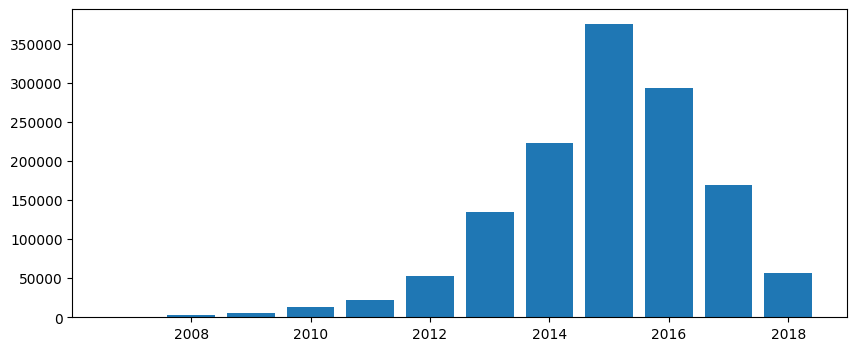

In [29]:
yearly = (
    df_resolved
    .groupby("issue_year")
    .agg(
        loan_count   = ("loan_amnt", "count"),
        default_rate = ("default_flag", "mean")
    )
    .reset_index()
)

print(yearly.dtypes)
print()
print(yearly)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly["issue_year"], yearly["loan_count"])
plt.show()

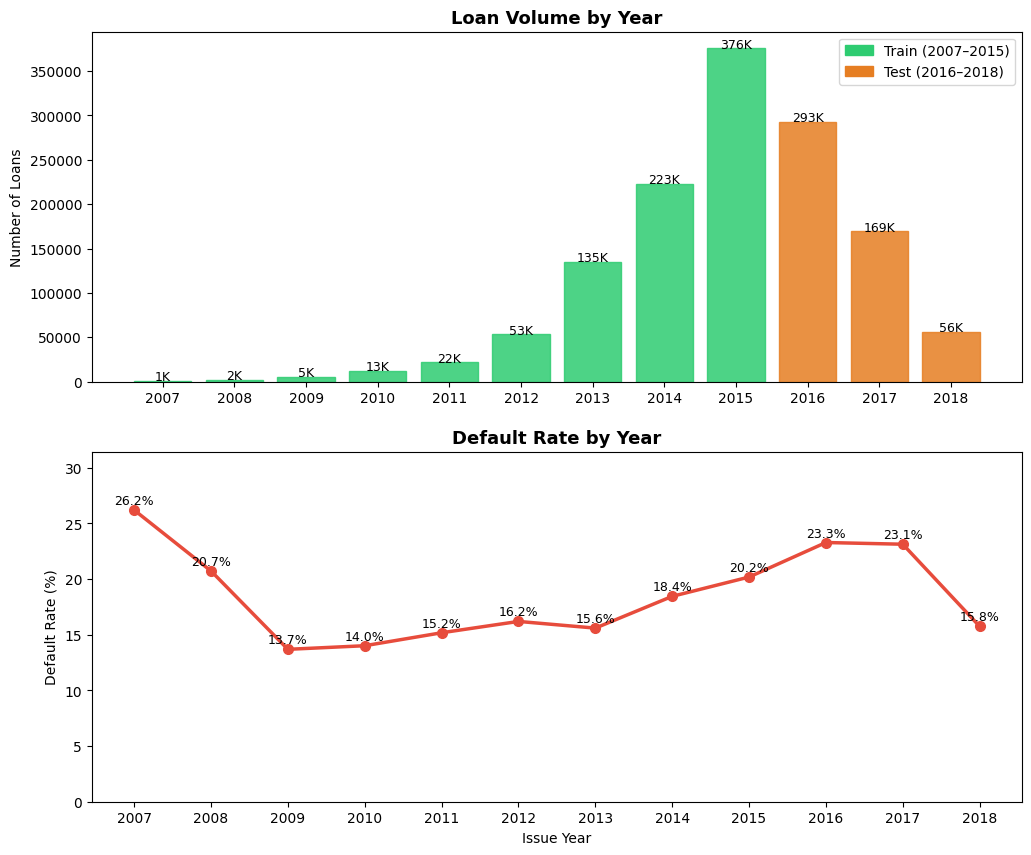

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ── Top: Loan volume by year ───────────────────────────────────────────────────
bars = axes[0].bar(yearly["issue_year"], yearly["loan_count"],
                   color="#3498db", alpha=0.85)
axes[0].set_title("Loan Volume by Year", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Loans")
axes[0].set_xticks(yearly["issue_year"])

for bar, count in zip(bars, yearly["loan_count"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f"{count/1e3:.0f}K", ha="center", fontsize=9)

# Train/test shading — use explicit x tick positions
for year in yearly["issue_year"]:
    color = "#2ecc71" if year <= 2015 else "#e67e22"
    bars[list(yearly["issue_year"]).index(year)].set_color(color)

axes[0].legend(
    handles=[
        plt.Rectangle((0,0),1,1, color="#2ecc71", label="Train (2007–2015)"),
        plt.Rectangle((0,0),1,1, color="#e67e22", label="Test (2016–2018)")
    ], fontsize=10
)

# ── Bottom: Default rate by year ───────────────────────────────────────────────
axes[1].plot(yearly["issue_year"], yearly["default_rate"] * 100,
             marker="o", color="#e74c3c", linewidth=2.5, markersize=7)
axes[1].set_title("Default Rate by Year", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Default Rate (%)")
axes[1].set_xlabel("Issue Year")
axes[1].set_xticks(yearly["issue_year"])
axes[1].set_ylim(0, yearly["default_rate"].max() * 100 * 1.2)

for _, row in yearly.iterrows():
    axes[1].text(row["issue_year"], row["default_rate"] * 100 + 0.5,
                 f"{row['default_rate']*100:.1f}%", ha="center", fontsize=9)

**Loan volume:**
Lending Club grew rapidly from 603 loans in 2007 to a peak of 376K in 2015,
then declined through 2018. The 2018 figure (56K) is a partial year.
Training set (2007–2015) contains ~830K resolved loans, test set (2016–2018)
contains ~518K — a roughly 60/40 split by volume.

**Default rate pattern:**
- 2007–2008 (26.2%, 20.7%): high default rate on early loans. Small sample
  (603 and 2,393 loans) — noisy estimates, treat with caution.
- 2009–2013 (13.7%–16.2%): post-crisis stabilisation. Lending Club tightened
  underwriting standards following 2008. Lowest default rates in the dataset.
- 2014–2017 (18.4%–23.3%): steady rise. Platform scaled aggressively,
  credit standards loosened, more higher-risk borrowers admitted.
- 2018 (15.8%): apparent drop, but misleading — 2018 loans have not had
  sufficient time to mature and default. Many will still charge off after
  the data snapshot date. This is a censoring artefact, not improvement.

Default rate is not stable over time — it ranges from 13.7% to 26.2%.
A random train/test split would leak future loans into training, allowing
the model to learn patterns from credit vintages it should never have seen.
Temporal split (train 2007–2015, test 2016–2018) mirrors how a model would
actually be deployed: trained on historical loans, evaluated on future ones.

##  Section 7: Feature Correlation Overview 

In [31]:
# Pearson correlation of all numeric features with default_flag
numeric_cols = df_resolved.select_dtypes(include="number").columns.tolist()

# Remove target and helper columns
exclude = ["default_flag", "issue_year", "fico_range_high"]
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr_with_target = (
    df_resolved[numeric_cols + ["default_flag"]]
    .corr()["default_flag"]
    .drop("default_flag")
    .sort_values(key=abs, ascending=False)
)

print("Numeric features ranked by absolute correlation with default_flag:")
print()
print(corr_with_target.round(4).to_string())

Numeric features ranked by absolute correlation with default_flag:

last_fico_range_high                         -0.6671
last_fico_range_low                          -0.5750
recoveries                                    0.5047
collection_recovery_fee                       0.4791
total_rec_prncp                              -0.4389
last_pymnt_amnt                              -0.3472
total_pymnt                                  -0.3153
total_pymnt_inv                              -0.3148
int_rate                                      0.2586
sec_app_fico_range_high                      -0.2518
sec_app_fico_range_low                       -0.2518
hardship_dpd                                  0.2449
hardship_amount                               0.1737
orig_projected_additional_accrued_interest    0.1731
hardship_payoff_balance_amount                0.1628
sec_app_mths_since_last_major_derog          -0.1599
sec_app_inq_last_6mths                        0.1511
sec_app_mort_acc               

In [32]:
# Correlation with default_flag, leakage excluded

leakage_set = set(leakage_present)

numeric_cols = df_resolved.select_dtypes(include="number").columns.tolist()
exclude = leakage_set | {
    "default_flag", "issue_year", "fico_range_high",
    "member_id", "policy_code"
}
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr_with_target = (
    df_resolved[numeric_cols + ["default_flag"]]
    .corr()["default_flag"]
    .drop("default_flag")
    .dropna()
    .sort_values(key=abs, ascending=False)
)

print("Numeric features ranked by absolute correlation with default_flag")
print("(leakage columns excluded):")
print()
print(corr_with_target.round(4).to_string())

Numeric features ranked by absolute correlation with default_flag
(leakage columns excluded):

int_rate                               0.2586
sec_app_fico_range_high               -0.2518
sec_app_fico_range_low                -0.2518
sec_app_mths_since_last_major_derog   -0.1599
sec_app_inq_last_6mths                 0.1511
sec_app_mort_acc                      -0.1420
sec_app_revol_util                     0.1416
dti_joint                              0.1405
fico_range_low                        -0.1307
sec_app_collections_12_mths_ex_med     0.1075
acc_open_past_24mths                   0.0999
annual_inc_joint                      -0.0907
all_util                               0.0890
num_tl_op_past_12m                     0.0856
dti                                    0.0842
bc_open_to_buy                        -0.0820
open_rv_24m                            0.0819
avg_cur_bal                           -0.0789
tot_hi_cred_lim                       -0.0785
mort_acc                       

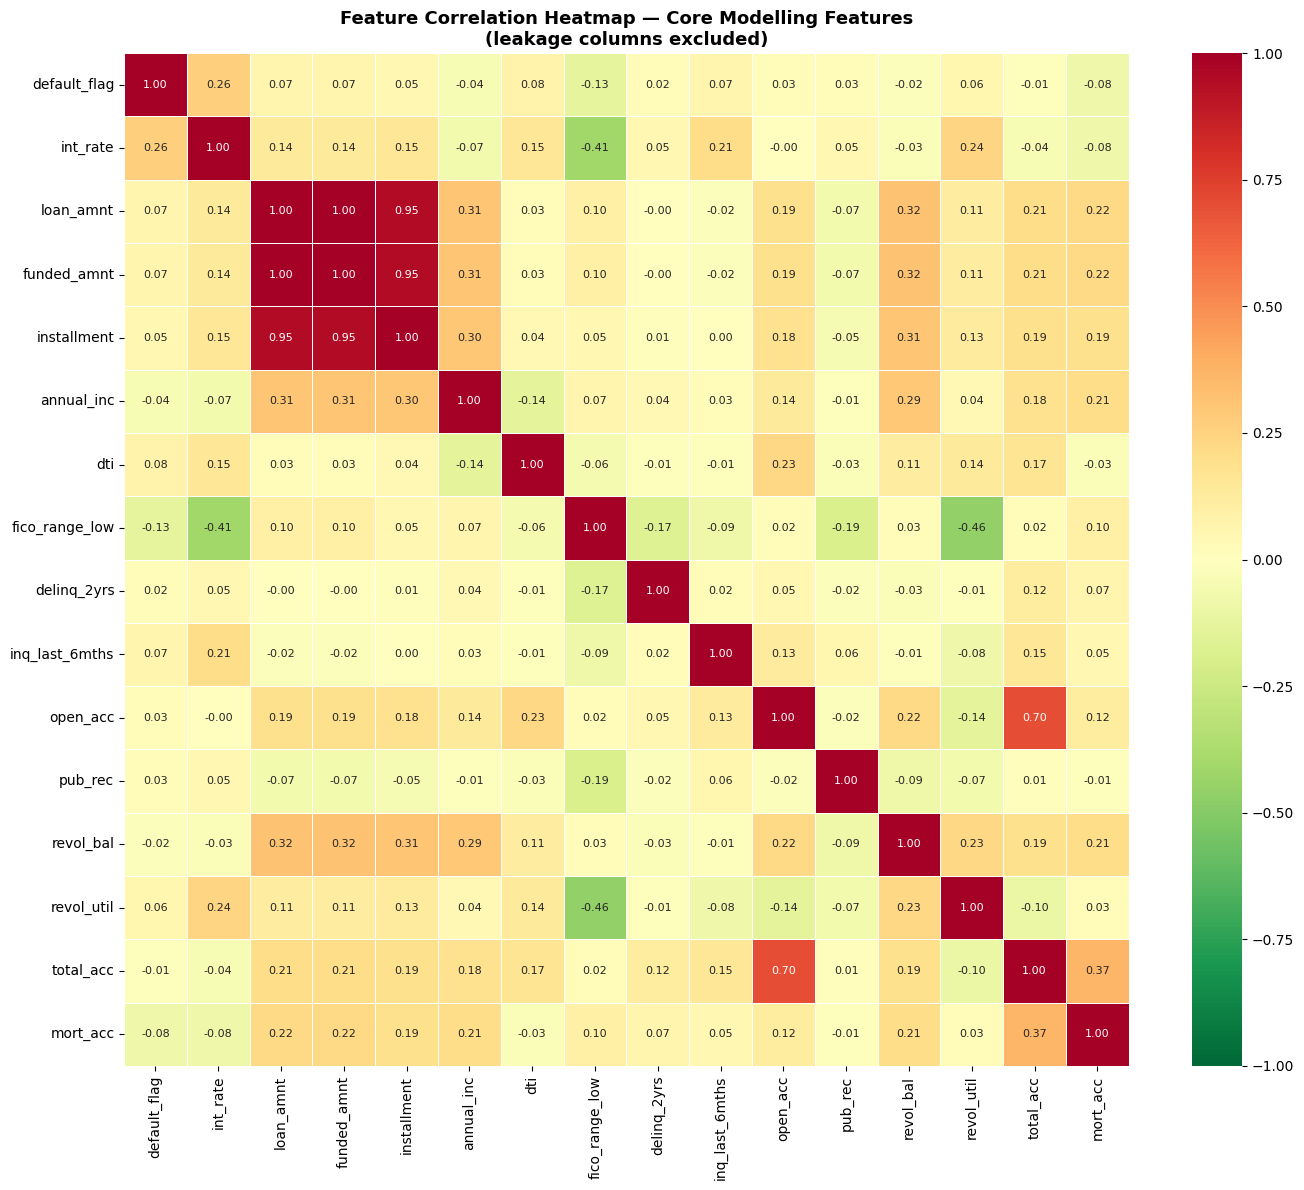

Saved: outputs/correlation_heatmap.png


In [33]:
# Correlation heatmap, core modelling features only

core_features = [
    "default_flag",
    "int_rate", "loan_amnt", "funded_amnt", "installment",
    "annual_inc", "dti", "fico_range_low",
    "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc", "mort_acc"
]

corr_matrix = df_resolved[core_features].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title(
    "Feature Correlation Heatmap — Core Modelling Features\n"
    "(leakage columns excluded)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/correlation_heatmap.png")

No single numeric feature is strongly predictive in isolation. The highest
legitimate correlation is `int_rate` at 0.26. This is expected — credit
default is driven by the combination of many weak signals, not one dominant
feature. Predictive power emerges from the model, not from individual
pairwise correlations.

**Notable correlations with default_flag:**
- `int_rate` (0.26) — strongest predictor, encodes Lending Club's risk
  assessment at origination
- `fico_range_low` (−0.13) — higher FICO, lower default probability
- `revol_util` (0.06), `dti` (0.08), `inq_last_6mths` (0.07) — weak but
  directionally sensible

**Key finding:** The first correlation table (before leakage removal) showed
`last_fico_range_high` at −0.667 and `recoveries` at 0.505. After removing
leakage columns, the top correlation drops to 0.26. This demonstrates
concretely why leakage identification is a prerequisite to any modelling work.

## EDA Summary 

#### 8.1 — Columns to Drop

**Post-origination leakage (36 columns) — Section 3**
Drop all columns in `leakage_present`. These contain information unavailable
at loan application time. Keeping them would cause severe data leakage.

**Tier 1 — >50% missing (58 columns) — Section 3**
Drop all columns in `tier_drop`. Includes hardship block, settlement block,
joint application block, and most `mths_since_*` columns.

**Administrative — no signal (Section 1)**
Drop: `id`, `member_id`, `url`, `desc`, `title`, `zip_code`, `policy_code`

**Redundant features — Section 7**
Drop: `funded_amnt` (corr 0.99 with `loan_amnt`)
Review: `installment` (corr 0.95 with `loan_amnt`) — drop after IV check

**No discriminatory power — Section 5**
Drop: `initial_list_status`, `disbursement_method`, `pymnt_plan`,
`application_type`

**Borderline — low signal**
Drop: `emp_title` (free text, high cardinality, 6.38% missing)
Drop: `addr_state` (narrow default rate range across states)

---

#### 8.2 — Columns to Impute

**`mths_since_last_delinq` (50.4% missing) — Section 3**
- Create binary indicator: `ever_delinq` = 1 if not missing, 0 if missing
- Impute missing values with large sentinel value (e.g. 999)
- Rationale: missing means never delinquent — absence is informative

**`mths_since_recent_inq` (13.12% missing) — Section 3**
- Impute missing with sentinel value 999
- Rationale: missing means no recent inquiry

**`emp_length` (5.83% missing) — Section 3**
- Impute missing with "Unknown" category
- Keep as ordinal feature for WoE encoding

**`revol_util` (0.07% missing) — Section 4**
- Impute with median

**`num_*` / `mo_sin_*` credit bureau block (5.21% missing) — Section 3**
- Decision deferred: nearly all training data (2007–2015) is missing these
  features due to late addition to Lending Club data
- Action: drop this block from the feature set for logistic regression;
  may revisit for gradient boosting which handles missingness more robustly

**Remaining Tier 3 columns (<5% missing)**
- Impute numeric columns with median
- Impute categorical columns with mode

---

#### 8.3 — Transformations Required

**`annual_inc` — Section 4**
- Apply log transformation: `log_annual_inc = log(annual_inc + 1)`
- Rationale: extreme right skew, large outliers

**`loan_amnt`, `revol_bal` — Section 4**
- Consider log transformation after reviewing distributions post-cleaning

**`issue_d` — Section 6**
- Already parsed to `issue_year` in this notebook
- Drop raw `issue_d` and `issue_d_parsed` in Notebook 02

---

#### 8.4 — Train / Test Split

**Temporal split — Section 6**
- Train: loans issued 2007–2015 (~830K resolved loans)
- Test: loans issued 2016–2018 (~518K resolved loans)
- No random split — preserves temporal integrity
- Note: 2018 loans may be subject to censoring (insufficient time to default)

---

#### 8.5 — Features Confirmed for Modelling

After all drops and transformations, the confirmed feature set entering
Notebook 04 (WoE encoding and feature selection):

**Numeric:**
`int_rate`, `loan_amnt`, `annual_inc` (log), `dti`, `fico_range_low`,
`inq_last_6mths`, `open_acc`, `pub_rec`, `revol_bal`, `revol_util`,
`total_acc`, `mort_acc`, `delinq_2yrs`, `mths_since_last_delinq`
(with `ever_delinq` flag), `mths_since_recent_inq`

**Categorical (WoE encoding):**
`grade`, `sub_grade`, `term`, `purpose`, `verification_status`,
`home_ownership`, `emp_length`

**Target:** `default_flag`#### 8.1 — Columns to Drop

**Post-origination leakage (36 columns) — Section 3**
Drop all columns in `leakage_present`. These contain information unavailable
at loan application time. Keeping them would cause severe data leakage.

**Tier 1 — >50% missing (58 columns) — Section 3**
Drop all columns in `tier_drop`. Includes hardship block, settlement block,
joint application block, and most `mths_since_*` columns.

**Administrative — no signal (Section 1)**
Drop: `id`, `member_id`, `url`, `desc`, `title`, `zip_code`, `policy_code`

**Redundant features — Section 7**
Drop: `funded_amnt` (corr 0.99 with `loan_amnt`)
Review: `installment` (corr 0.95 with `loan_amnt`) — drop after IV check

**No discriminatory power — Section 5**
Drop: `initial_list_status`, `disbursement_method`, `pymnt_plan`,
`application_type`

**Borderline — low signal**
Drop: `emp_title` (free text, high cardinality, 6.38% missing)
Drop: `addr_state` (narrow default rate range across states)

---

#### 8.2 — Columns to Impute

**`mths_since_last_delinq` (50.4% missing) — Section 3**
- Create binary indicator: `ever_delinq` = 1 if not missing, 0 if missing
- Impute missing values with large sentinel value (e.g. 999)
- Rationale: missing means never delinquent — absence is informative

**`mths_since_recent_inq` (13.12% missing) — Section 3**
- Impute missing with sentinel value 999
- Rationale: missing means no recent inquiry

**`emp_length` (5.83% missing) — Section 3**
- Impute missing with "Unknown" category
- Keep as ordinal feature for WoE encoding

**`revol_util` (0.07% missing) — Section 4**
- Impute with median

**`num_*` / `mo_sin_*` credit bureau block (5.21% missing) — Section 3**
- Decision deferred: nearly all training data (2007–2015) is missing these
  features due to late addition to Lending Club data
- Action: drop this block from the feature set for logistic regression;
  may revisit for gradient boosting which handles missingness more robustly

**Remaining Tier 3 columns (<5% missing)**
- Impute numeric columns with median
- Impute categorical columns with mode

---

#### 8.3 — Transformations Required

**`annual_inc` — Section 4**
- Apply log transformation: `log_annual_inc = log(annual_inc + 1)`
- Rationale: extreme right skew, large outliers

**`loan_amnt`, `revol_bal` — Section 4**
- Consider log transformation after reviewing distributions post-cleaning

**`issue_d` — Section 6**
- Already parsed to `issue_year` in this notebook
- Drop raw `issue_d` and `issue_d_parsed` in Notebook 02

---

#### 8.4 — Train / Test Split

**Temporal split — Section 6**
- Train: loans issued 2007–2015 (~830K resolved loans)
- Test: loans issued 2016–2018 (~518K resolved loans)
- No random split — preserves temporal integrity
- Note: 2018 loans may be subject to censoring (insufficient time to default)

---

#### 8.5 — Features Confirmed for Modelling

After all drops and transformations, the confirmed feature set entering
Notebook 04 (WoE encoding and feature selection):

**Numeric:**
`int_rate`, `loan_amnt`, `annual_inc` (log), `dti`, `fico_range_low`,
`inq_last_6mths`, `open_acc`, `pub_rec`, `revol_bal`, `revol_util`,
`total_acc`, `mort_acc`, `delinq_2yrs`, `mths_since_last_delinq`
(with `ever_delinq` flag), `mths_since_recent_inq`

**Categorical (WoE encoding):**
`grade`, `sub_grade`, `term`, `purpose`, `verification_status`,
`home_ownership`, `emp_length`

**Target:** `default_flag`

In [34]:
import os
import pickle

os.makedirs("../data/processed", exist_ok=True)

df_resolved.to_pickle("../data/processed/df_resolved.pkl")

# Verify
df_check = pd.read_pickle("../data/processed/df_resolved.pkl")
assert df_check.shape == df_resolved.shape, "Shape mismatch after save"

print(f"Saved: data/processed/df_resolved.pkl")
print(f"Shape: {df_check.shape}")
print(f"Size:  {os.path.getsize('../data/processed/df_resolved.pkl') / 1e6:.1f} MB")

Saved: data/processed/df_resolved.pkl
Shape: (1348099, 154)
Size:  2005.5 MB
